<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
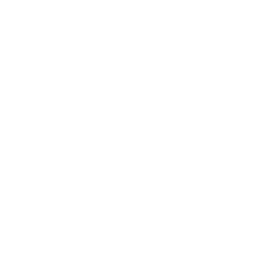
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">포아송 회귀분석을 이용한 이상반응 발생률 분석</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 제약 / 약물감시 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

시뮬레이션된 3상 임상시험에서 **로그 노출 오프셋을 포함한 포아송 회귀분석**으로 치료군별 이상반응(AE) 발생률을 추정한다. 각 환자는 서로 다른 추적관찰 기간 동안 AE 발생 건수를 기여하므로, 오프셋 `log(exposure_py)`는 모형을 건수 기준에서 *인년당 발생률* 기준으로 변환한다. 모형은 환자의 연령과 성별을 보정하며, Type 3 가능도비 분석은 각 효과를 검정한다. 위약 대비 발생률비는 모형 계수와 그 95% 신뢰한계를 지수변환하여 얻는다. 모수 추정값은 ODS OUTPUT을 통해 수집되며, 후속 보고 및 규제 제출용 표를 위해 CSV로 내보낸다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.AE_COUNTS | 노출 기간을 포함한 환자 수준 AE 발생 건수, 3개 치료군 | 100 |

코호트는 DRUG_HIGH, DRUG_LOW, PLACEBO 세 군에 걸쳐 1:1:1 균등 무작위배정으로 환자 100명을 시뮬레이션한 것이다. 추적관찰 기간은 환자마다 다르며(대략 0.2~1.0 인년), 이는 로그 노출 오프셋이 설계된 바로 그 상황이다.

---

In [1]:
/* --------------------------------------------------------
   환자 수준 이상반응(AE) 발생 건수 데이터 생성 (노출 기간 포함)
   제약 3상 임상시험: 3개 치료군, 환자 100명
   -------------------------------------------------------- */
데이터 work.ae_counts;
    호출 streaminit(42);
    배열 arm_list[3] $9 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    반복 patient_id = 1 까지 100;
        /* --- 1:1:1 균등 치료군 배정 --- */
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arm_list[arm_idx];

        /* --- 인구통계 정보 --- */
        AGE = int(rand('normal', 58, 11));
        만약 AGE < 18 이면 AGE = 18;
        만약 AGE > 85 이면 AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');

        /* --- 노출 기간(인년), 추적관찰 기간은 환자마다 다름 --- */
        exposure_days = int(rand('uniform') * 300) + 60;
        exposure_py   = round(exposure_days / 365.25, 0.001);
        log_exposure  = LOG(exposure_py);

        /* --- 이상반응 발생 건수: 노출 기간에 비례하는 포아송 발생률 --- */
        만약 treatment = 'DRUG_HIGH' 이면 base_rate = 6.0;
        아니면 만약 treatment = 'DRUG_LOW' 이면 base_rate = 3.2;
        아니면 base_rate = 1.6;
        rate = base_rate * (1 + 0.012 * (AGE - 58));
        만약 sex = 'M' 이면 rate = rate * 1.25;
        ae_count = rand('poisson', rate * exposure_py);

        출력;
    종료;
    제거 arm_idx base_rate rate;
실행;


NOTE: DATA work.ae_counts


NOTE: Wrote work.ae_counts (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

In [2]:
/* --------------------------------------------------------
   치료군별 기저 이상반응 발생 건수 분포
   -------------------------------------------------------- */
처리 평균 데이터=work.ae_counts n sum mean std MIN MAX;
    분류 treatment;
    변수 ae_count exposure_py;
    라벨 treatment   = "치료군"
          ae_count    = "이상반응 발생 건수"
          exposure_py = "노출 기간(인년)";
실행;

                                                  The MEANS Procedure

                                Analysis Variable : ae_count 이상반응 발생 건수

        치료군                N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        DRUG_HIGH             34    112.0000000      3.2941176      2.8975372      0.0000000     12.0000000
        DRUG_LOW              33     50.0000000      1.5151515      1.0037807      0.0000000      3.0000000
        PLACEBO               33     37.0000000      1.1212121      1.1390121      0.0000000      4.0000000
        ---------------------------------------------------------------------------------------------------

                                 Analysis Variable : exposure_py 노출 기간(인년)

        치료군                N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        ---------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.ae_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


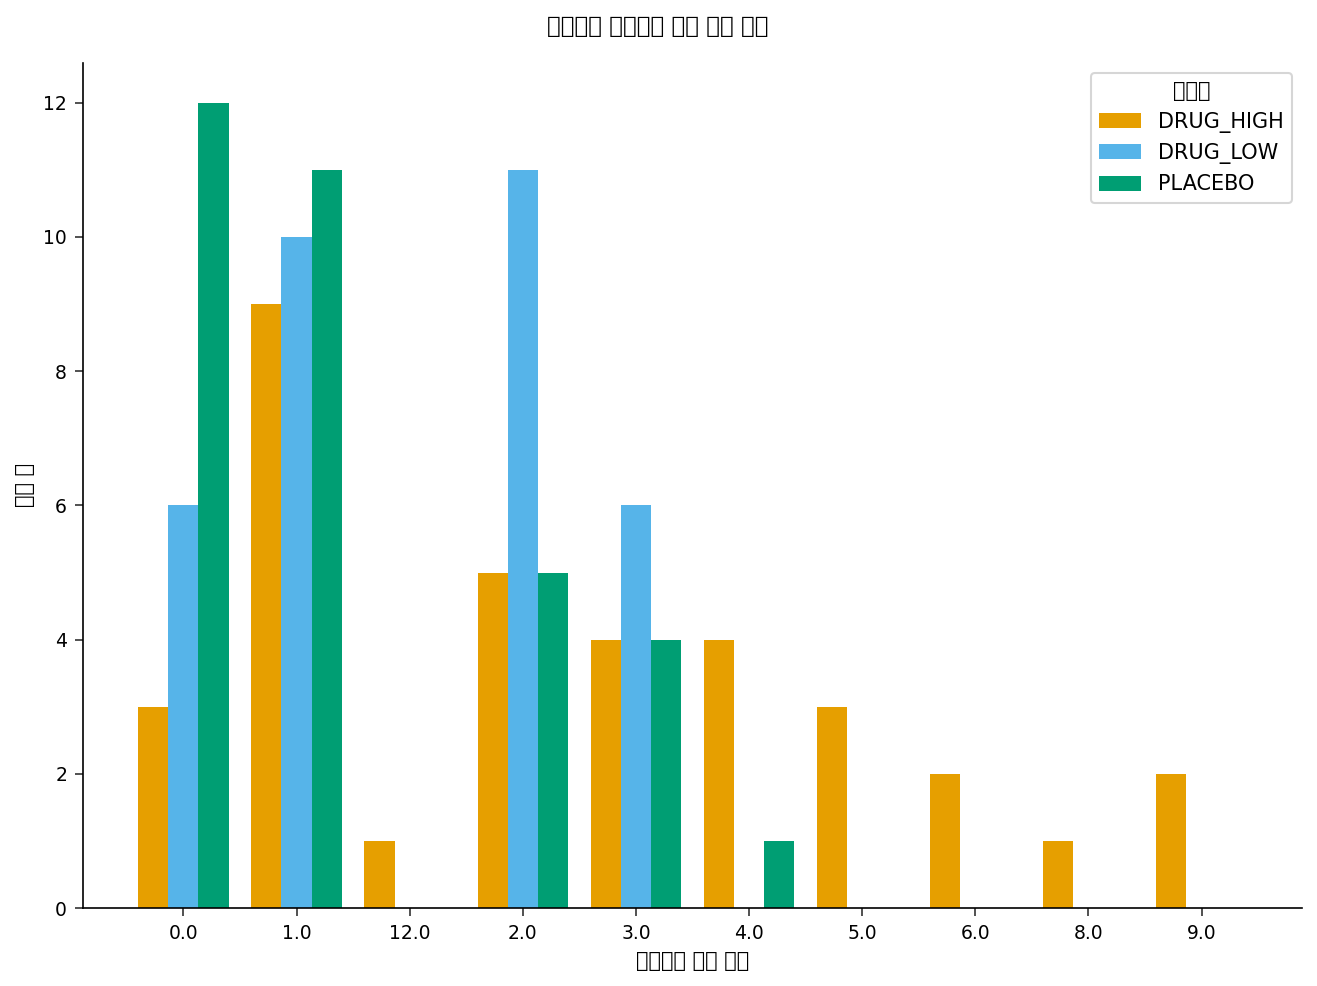

In [3]:
/* --------------------------------------------------------
   치료군별 이상반응 발생 건수 분포
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.ae_counts;
    VBAR ae_count / GROUP=treatment GROUPDISPLAY=CLUSTER;
    keylegend / 제목="치료군";
    XAXIS 라벨="이상반응 발생 건수" integer;
    YAXIS 라벨="환자 수";
    제목 "치료군별 이상반응 발생 건수 분포";
실행;

---

        The GENMOD Procedure        
         Model Information          

Item                           Value
----------------------  ------------
Response Variable           AE_COUNT
Distribution                 poisson
Link Function                    log
Number of Observations           100
Offset Variable         LOG_EXPOSURE

      Analysis of Maximum Likelihood Parameter Estimates       

Parameter           Estimate  Std Error  Chi-Square  Pr > ChiSq
------------------  --------  ---------  ----------  ----------
(Intercept)          -0.3910     0.3832      1.0411      0.3076
TREATMENTDRUG_HIGH    1.1236     0.1913     34.4851      <.0001
TREATMENTDRUG_LOW     0.4713     0.2172      4.7101      0.0300
AGE                   0.0178     0.0060      8.9054      0.0028
SEXM                 -0.0043     0.1494      0.0008      0.9769

Criteria for Assessing Goodness of Fit

Criterion           Value
--------------  ---------
Deviance          98.4367
Log Likelihood  -152.8389
AIC    


NOTE: PROC GENMOD data=work.ae_counts

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: AE_COUNT
NOTE: Distribution: POISSON
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.
NOTE: PROC GENMOD: Emitting ODS OUTPUT datasets (1 destination(s))
NOTE: DATA work.genmod_rr


NOTE: Read 5 rows from work.genmod_parms.
NOTE: Wrote work.genmod_rr (4 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


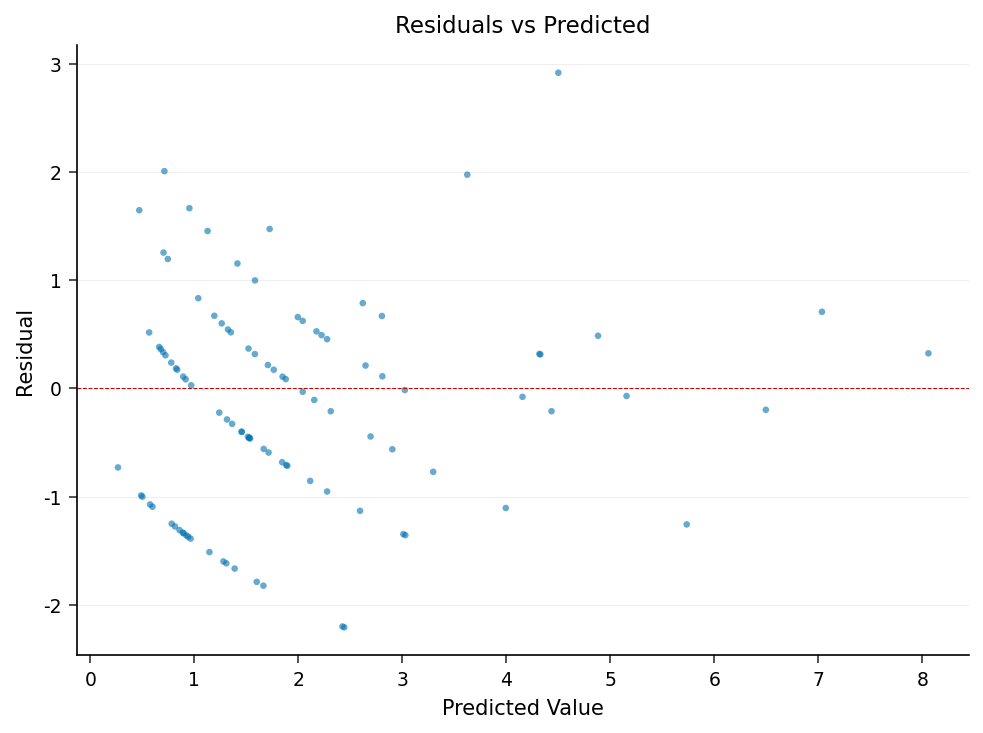

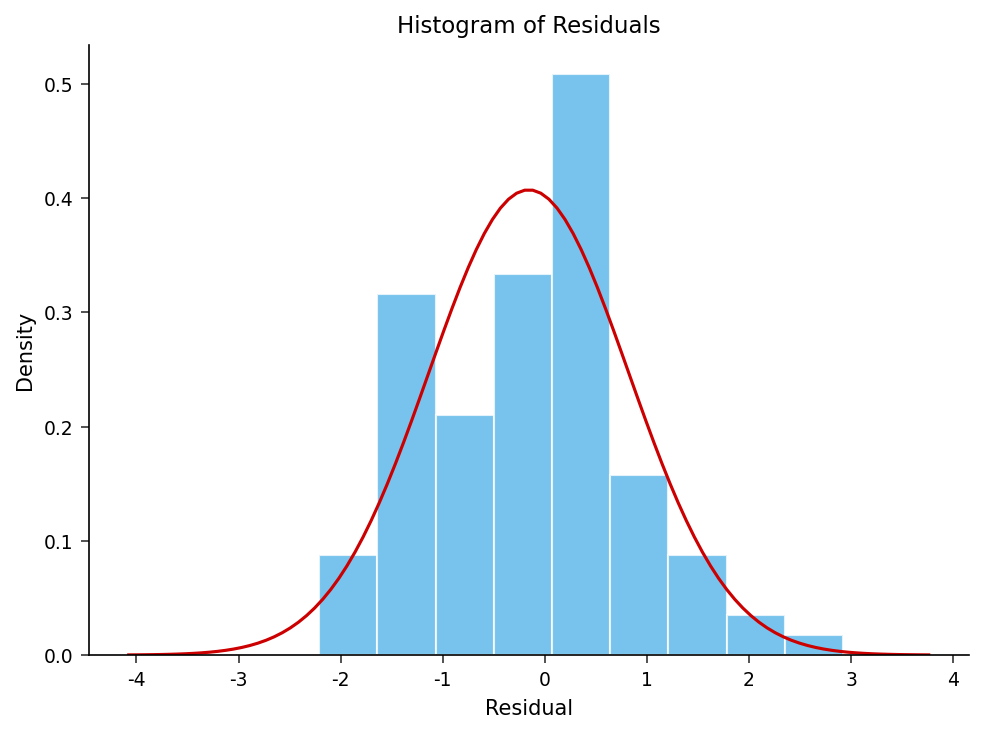

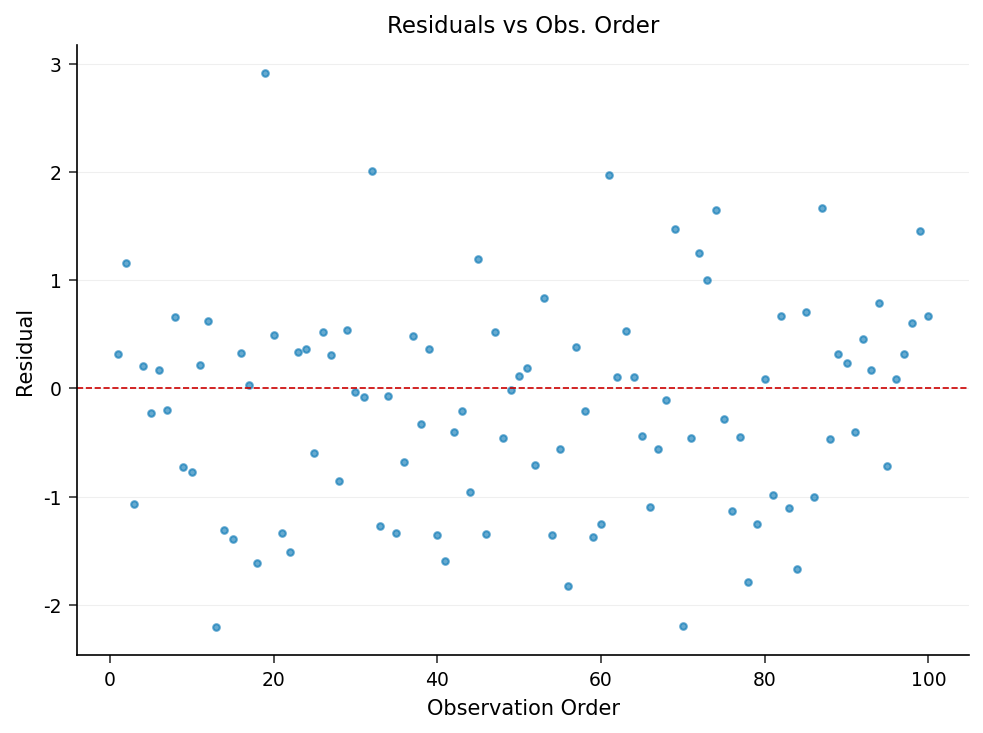

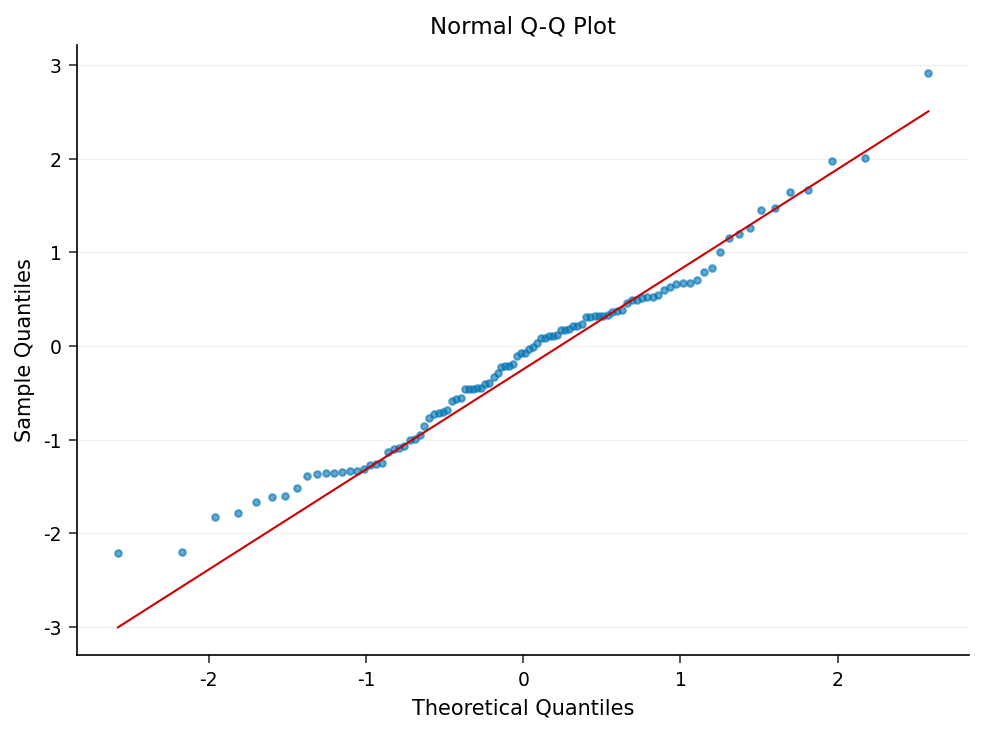

In [4]:
/* --------------------------------------------------------
   이상반응 발생률에 대한 포아송 회귀분석
   OFFSET = log(exposure) -> 계수는 로그 발생률비를 의미
   TYPE3 -> 각 효과에 대한 가능도비 검정
   -------------------------------------------------------- */
처리 GENMOD 데이터=work.ae_counts;
    분류 treatment (REF='PLACEBO') sex (REF='F');
    모형 ae_count = treatment AGE sex
        / DIST=poisson
          LINK=LOG
          OFFSET=log_exposure
          type3;
    ODS 출력 parameterestimates=work.genmod_parms;
실행;

/* --------------------------------------------------------
   로그 계수를 95% 신뢰구간을 포함한 발생률비로 변환.
   exp(estimate)는 다른 공변량을 고정했을 때
   인년당 이상반응 발생률에 대한 배수 효과를 의미한다.
   -------------------------------------------------------- */
데이터 work.genmod_rr;
    설정 work.genmod_parms;
    조건 parameter 아닌 IN ('(Intercept)', 'Scale');
    rate_ratio  = EXP(estimate);
    rr_lower_cl = EXP(lowercl);
    rr_upper_cl = EXP(uppercl);
    형식 rate_ratio rr_lower_cl rr_upper_cl 6.3;
    유지 parameter estimate stderr probchisq
         rate_ratio rr_lower_cl rr_upper_cl;
실행;

In [5]:
/* --------------------------------------------------------
   발생률비 추정값 검토
   -------------------------------------------------------- */
처리 인쇄 데이터=work.genmod_rr 라벨 noobs;
    라벨 parameter   = "효과"
          rate_ratio  = "발생률비"
          rr_lower_cl = "95% 신뢰구간 하한"
          rr_upper_cl = "95% 신뢰구간 상한"
          probchisq   = "카이제곱 유의확률";
    변수 parameter rate_ratio rr_lower_cl rr_upper_cl probchisq;
    제목 "이상반응 발생률비(기준군 대비)";
실행;

                                                   이상반응 발생률비(기준군 대비)                                                    

                효과          발생률비              95% 신뢰구간 하한              95% 신뢰구간 상한                  카이제곱 유의확률
TREATMENTDRUG_HIGH         3.076                    2.114                    4.476               0.0000000043
TREATMENTDRUG_LOW          1.602                    1.047                    2.452               0.0299864864
AGE                        1.018                    1.006                    1.030               0.0028433634
SEXM                       0.996                    0.743                    1.334               0.9769198944




NOTE: PROC PRINT data=work.genmod_rr

NOTE: PROC PRINT completed: 4 observations printed, 5 variables


---

### 해석

로그 노출 오프셋을 포함한 포아송 회귀분석은 이상반응 발생률에 대해 명확하고 통계적으로 유의한 용량 의존적 효과를 보여준다. 치료군에 대한 Type 3 가능도비 검정은 매우 유의하다(χ² = 39.11, 자유도 2, *p* < .0001).

- **고용량 대 위약:** 발생률비 **3.08**(95% 신뢰구간 2.11~4.48), *p* < .0001 — 고용량군 환자는 인년당 노출당 위약군의 약 3배에 달하는 AE 발생률을 보인다.
- **저용량 대 위약:** 발생률비 **1.60**(95% 신뢰구간 1.05~2.45), *p* = 0.030 — 보다 완만하지만 여전히 유의한 상승으로, 용량-반응 경사와 일치한다.
- **연령:** 1세 증가할 때마다 AE 발생률이 **1.8%** 증가하는 것과 관련이 있다(연간 발생률비 1.018, 95% 신뢰구간 1.006~1.030; Type 3 *p* = 0.0028).
- **성별:** 보정 후 남성 대 여성 발생률비는 **0.996**(*p* = 0.977)이다 — 이 코호트에서 성별은 유의한 예측인자가 **아니다**.

모형은 관측치 100건에 대해 이탈도(deviance) 98.44, AIC 315.68로 적합되었다. 기술통계량의 평균 역시 이러한 경사를 뒷받침한다: 평균 AE 발생 건수는 고용량군 3.29건, 저용량군 1.52건, 위약군 1.12건이다. 이러한 결과는 용량 의존적 안전성 모니터링을 뒷받침하며, 데이터안전성모니터링위원회(DSMB)의 유익성-위해성 평가에 참고자료가 될 수 있다.

---

In [6]:
/* --------------------------------------------------------
   규제 제출용 표를 위한 추정값 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.genmod_parms
    OUTFILE='ae_rate_parameter_estimates.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.genmod_rr
    OUTFILE='ae_rate_ratios.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=work.genmod_parms outfile=ae_rate_parameter_estimates.csv

NOTE: Exported 5 rows to ae_rate_parameter_estimates.csv.
NOTE: PROC EXPORT data=work.genmod_rr outfile=ae_rate_ratios.csv

NOTE: Exported 4 rows to ae_rate_ratios.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner (<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">docs.jenneranalytics.com</a>) 제공
</div>
</div>